In [1]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


## Data Overview

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

sns.set(style="whitegrid")

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.shape

(7043, 21)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


## Data Cleaning

In [6]:
print("Shape before cleaning:", df.shape)

Shape before cleaning: (7043, 21)


In [7]:
# Fix TotalCharges
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Check missing
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [8]:
# Drop missing rows
df = df.dropna()

In [9]:
# Drop irrelevant column
df = df.drop("customerID", axis=1)

In [10]:
# Convert target
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

In [11]:
print("Duplicates before:", df.duplicated().sum())

df = df.drop_duplicates()

print("Duplicates after:", df.duplicated().sum())

Duplicates before: 22
Duplicates after: 0


In [12]:
# after cleaning steps
print("Shape after cleaning:", df.shape)

Shape after cleaning: (7010, 20)


## Exploratory Data Analysis

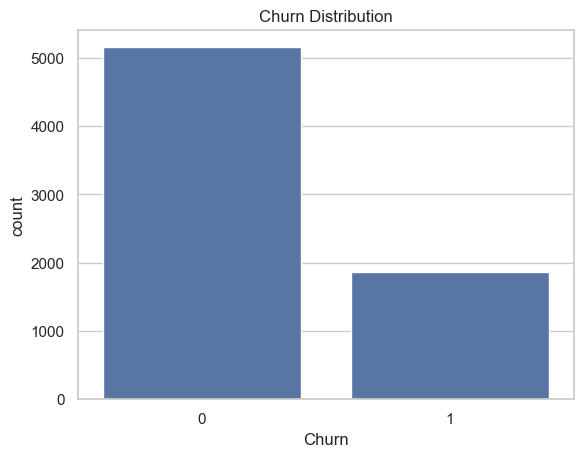

In [13]:
sns.countplot(x="Churn", data=df)
plt.title("Churn Distribution")
plt.show()

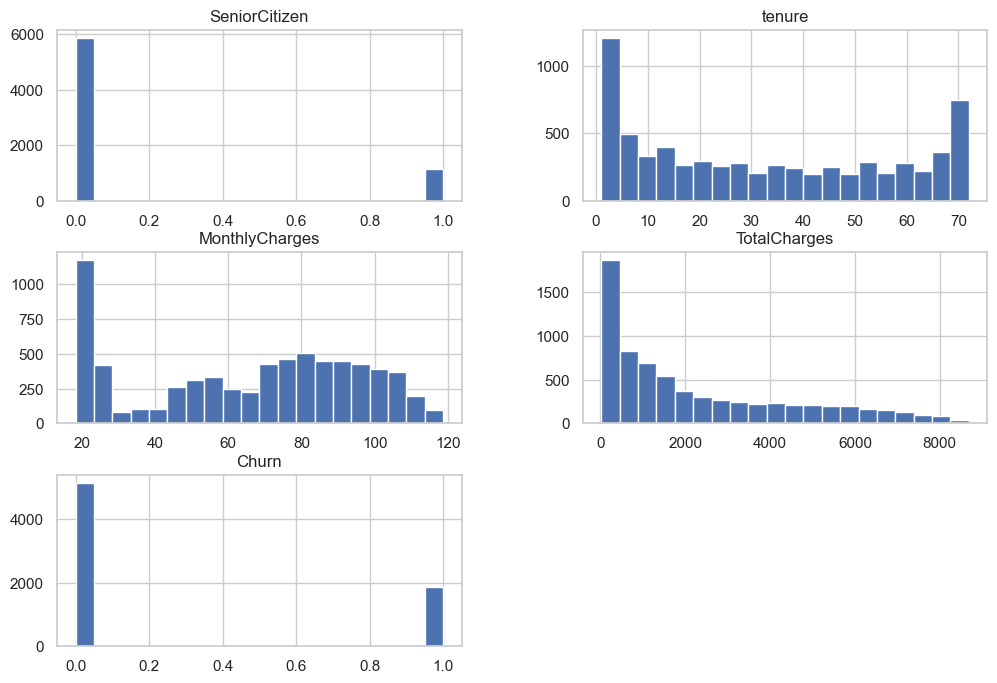

In [14]:
df.hist(bins=20, figsize=(12,8))
plt.show()

### Feature Relationships and Insights

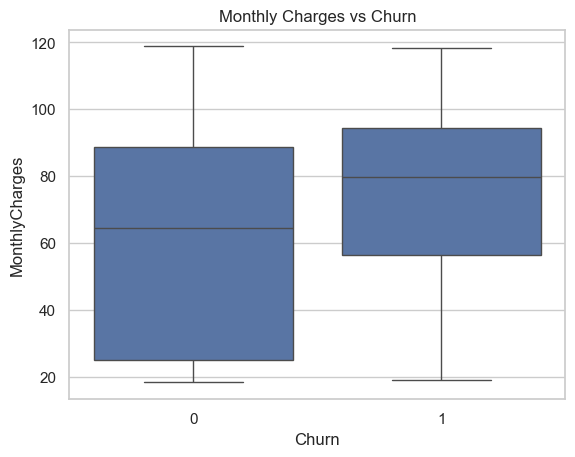

In [15]:
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

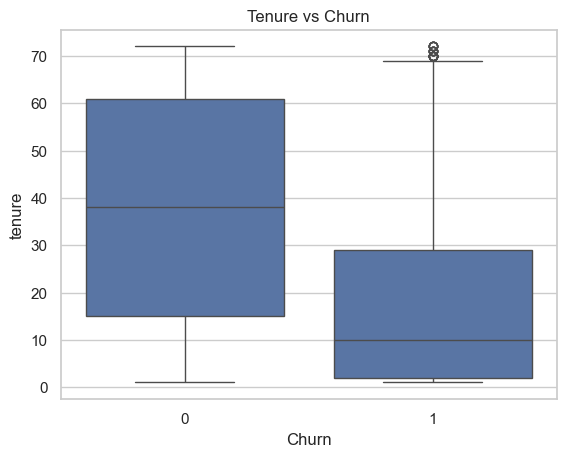

In [16]:
sns.boxplot(x="Churn", y="tenure", data=df)
plt.title("Tenure vs Churn")
plt.show()

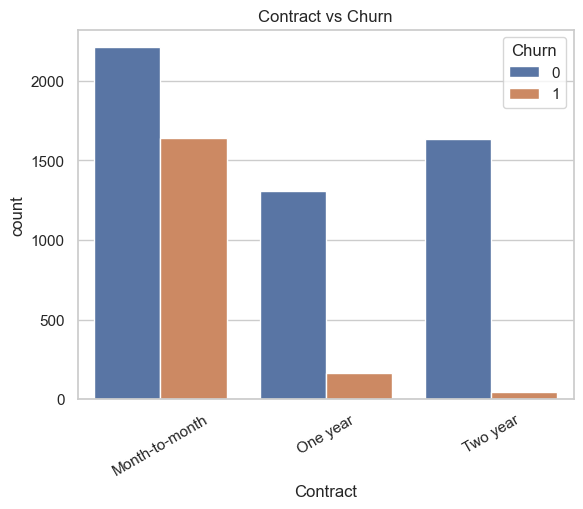

In [17]:
sns.countplot(x="Contract", hue="Churn", data=df)
plt.xticks(rotation=30)
plt.title("Contract vs Churn")
plt.show()

In [18]:
df["Churn"].value_counts(normalize=True) * 100

Churn
0    73.509272
1    26.490728
Name: proportion, dtype: float64

In [19]:
df.groupby("Churn")[["tenure", "MonthlyCharges", "TotalCharges"]].mean()

,tenure,MonthlyCharges,TotalCharges
Churn,,,
0,37.721133,61.387415,2560.264118
1,18.088853,74.604308,1541.376548


In [20]:
df.groupby("Contract")["Churn"].mean() * 100

Contract
Month-to-month    42.642097
One year          11.277174
Two year           2.848665
Name: Churn, dtype: float64

In [21]:
df.groupby("InternetService")["Churn"].mean() * 100

InternetService
DSL            18.931234
Fiber optic    41.779935
No              7.237716
Name: Churn, dtype: float64

In [22]:
df.groupby("PaymentMethod")["Churn"].mean() * 100

PaymentMethod
Bank transfer (automatic)    16.731518
Credit card (automatic)      15.253123
Electronic check             45.146248
Mailed check                 19.017632
Name: Churn, dtype: float64

In [23]:
df.groupby("TechSupport")["Churn"].mean() * 100

TechSupport
No                     41.512702
No internet service     7.237716
Yes                    15.196078
Name: Churn, dtype: float64

In [24]:
# Churn rate %
churn_rate = df["Churn"].value_counts(normalize=True) * 100
print(churn_rate)

Churn
0    73.509272
1    26.490728
Name: proportion, dtype: float64


In [25]:
# Group churn rate
contract_churn = df.groupby("Contract")["Churn"].mean() * 100
print(contract_churn)

Contract
Month-to-month    42.642097
One year          11.277174
Two year           2.848665
Name: Churn, dtype: float64


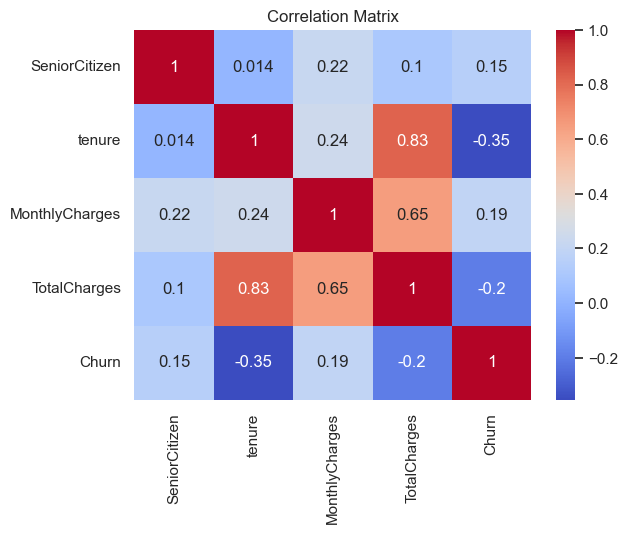

In [26]:
numeric_df = df.select_dtypes(include=["int64", "float64"])

sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

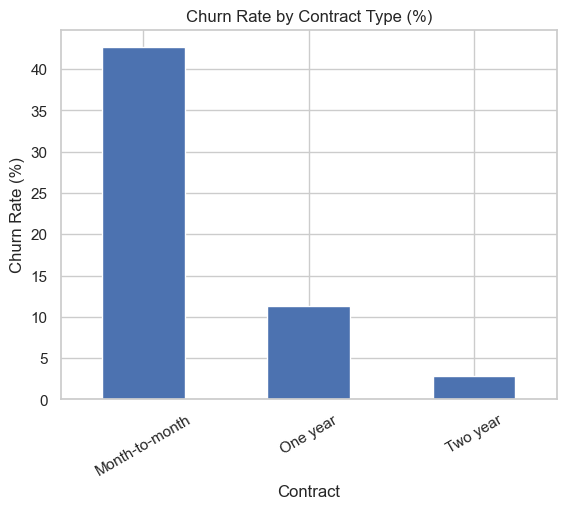

In [27]:
contract_churn.plot(kind="bar")
plt.title("Churn Rate by Contract Type (%)")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=30)
plt.show()

## Feature Importance Analysis

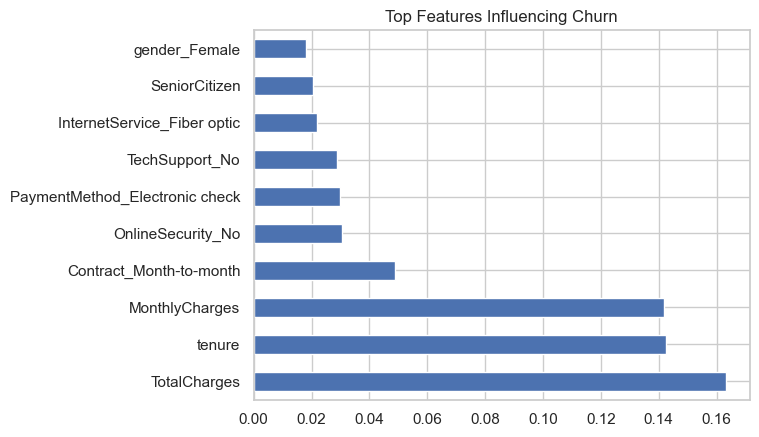

In [28]:
from sklearn.ensemble import RandomForestClassifier

X = pd.get_dummies(df.drop("Churn", axis=1))
y = df["Churn"]

model = RandomForestClassifier()
model.fit(X, y)

importance = pd.Series(model.feature_importances_, index=X.columns)

importance.nlargest(10).plot(kind="barh")
plt.title("Top Features Influencing Churn")
plt.show()

In [29]:
df.to_csv("clean_dataset.csv", index=False)

## Key Insights

### 1. Overall Churn Rate
Approximately **26.58% of customers have churned**, while **73.42% have remained**, indicating that although most customers stay, a significant portion still leaves the service.

---

### 2. Tenure and Customer Retention
Customers who churn have a significantly lower average tenure (**18.09 months**) compared to those who remain (**37.72 months**).  
This suggests that newer customers are far more likely to leave early, making early-stage retention critical.

---

### 3. Monthly Charges and Churn
Churned customers have a higher average monthly charge (**R74.60**) compared to retained customers (**R61.39**).  
This indicates that higher pricing may contribute to customer dissatisfaction and increased churn risk.

---

### 4. Contract Type Impact
Contract type has a strong influence on churn:
- **Month-to-month:** 42.64% churn rate  
- **One-year:** 11.28%  
- **Two-year:** 2.85%  

Customers on month-to-month contracts are significantly more likely to churn, while long-term contracts greatly improve retention.

---

### 5. Internet Service Type
Churn rates vary significantly by internet service:
- **Fiber optic:** 41.78%  
- **DSL:** 18.93%  
- **No internet service:** 7.24%  

Customers using fiber optic services show the highest churn, possibly due to higher costs or service expectations.

---

### 6. Payment Method Influence
Payment method also affects churn:
- **Electronic check:** 45.15% (highest)  
- **Bank transfer (automatic):** 16.73%  
- **Credit card (automatic):** 15.25%  
- **Mailed check:** 19.02%  

Customers using electronic checks are far more likely to churn, suggesting a link between payment behavior and retention.

---

### 7. Technical Support and Churn
Technical support availability plays a key role:
- **No tech support:** 41.51% churn  
- **With tech support:** 15.20% churn  
- **No internet service:** 7.24%  

Customers without technical support are almost three times more likely to churn, highlighting the importance of customer support services.

---

## Business Recommendations

- Encourage customers to switch to long-term contracts to improve retention  
- Provide early engagement strategies for new customers  
- Review pricing strategies for high monthly charge customers  
- Investigate issues related to fiber optic services  
- Promote automatic payment methods over electronic checks  
- Improve access to and awareness of technical support services

# Data PreProcessing

#### Loading the cleaned dataset that will be used for preprocessing

In [30]:
df = pd.read_csv('clean_dataset.csv')
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


## Understanding the Data

In [31]:
# Whant to see the data frame characteristics.
#  does it have missing values? Its data types, column names and the number of rows?
df.info()

# See the descriptive statistics for the numerical columns
display(df.describe().T)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7010 entries, 0 to 7009
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7010 non-null   object 
 1   SeniorCitizen     7010 non-null   int64  
 2   Partner           7010 non-null   object 
 3   Dependents        7010 non-null   object 
 4   tenure            7010 non-null   int64  
 5   PhoneService      7010 non-null   object 
 6   MultipleLines     7010 non-null   object 
 7   InternetService   7010 non-null   object 
 8   OnlineSecurity    7010 non-null   object 
 9   OnlineBackup      7010 non-null   object 
 10  DeviceProtection  7010 non-null   object 
 11  TechSupport       7010 non-null   object 
 12  StreamingTV       7010 non-null   object 
 13  StreamingMovies   7010 non-null   object 
 14  Contract          7010 non-null   object 
 15  PaperlessBilling  7010 non-null   object 
 16  PaymentMethod     7010 non-null   object 


,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7010.0,0.162767,0.369180,0.00,0.0000,0.000,0.0000,1.00
tenure,7010.0,32.520399,24.520441,1.00,9.0000,29.000,56.0000,72.00
MonthlyCharges,7010.0,64.888666,30.064769,18.25,35.7500,70.400,89.9000,118.75
TotalCharges,7010.0,2290.353388,2266.820832,18.80,408.3125,1403.875,3807.8375,8684.80
Churn,7010.0,0.264907,0.441315,0.00,0.0000,0.000,1.0000,1.00


In [32]:
# Check for unique values
# This helps in identifying binary, categorical and numerical columns
df.nunique()

gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                72
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1584
TotalCharges        6530
Churn                  2
dtype: int64

In [33]:
# Checking for missing values
# this will tell us how many missing values we have in each column
df.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

## Standardising Text Values (Creating Uniformity)

In [34]:
# remove extra spaces, if any
df = df.apply(lambda x: x.str.strip() if x.dtype == 'object' else x)

# convert all letters to lowercase, ensuring consistency
df = df.apply(lambda x: x.str.lower() if x.dtype == 'object' else x)

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,female,0,yes,no,1,no,no phone service,dsl,no,yes,no,no,no,no,month-to-month,yes,electronic check,29.85,29.85,0
1,male,0,no,no,34,yes,no,dsl,yes,no,yes,no,no,no,one year,no,mailed check,56.95,1889.50,0
2,male,0,no,no,2,yes,no,dsl,yes,yes,no,no,no,no,month-to-month,yes,mailed check,53.85,108.15,1
3,male,0,no,no,45,no,no phone service,dsl,yes,no,yes,yes,no,no,one year,no,bank transfer (automatic),42.30,1840.75,0
4,female,0,no,no,2,yes,no,fiber optic,no,no,no,no,no,no,month-to-month,yes,electronic check,70.70,151.65,1


## Fixing Hidden Categories

In [35]:
# replaces "no internet service" and "no phone service" values in the columns to "no". To keep binary consistency
df.replace(
    {
        "no internet service" : "no",
        "no phone service" : "no"
        
    }, inplace =True 
)

print(df['OnlineSecurity'].unique())
print(df['OnlineBackup'].unique())
print(df['MultipleLines'].unique())
print(df['StreamingTV'].unique())
print(df['DeviceProtection'].unique())
print(df['TechSupport'].unique())
print(df['StreamingMovies'].unique())

['no' 'yes']
['yes' 'no']
['no' 'yes']
['no' 'yes']
['no' 'yes']
['no' 'yes']
['no' 'yes']


# Encode Variables

In [36]:
# manually encode textual binary columns to number, to prevent the addition of extra columns
binary_columns = ['Partner', 'Dependents', 'PhoneService', 'MultipleLines',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling']

for col in binary_columns :
    df[col] =df[col].map({'yes':1, 'no':0})

# Males:1, Females:0
df['gender'] = df['gender'].map({'male':1, 'female':0})
display(df.head())

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,0,dsl,0,1,0,0,0,0,month-to-month,1,electronic check,29.85,29.85,0
1,1,0,0,0,34,1,0,dsl,1,0,1,0,0,0,one year,0,mailed check,56.95,1889.50,0
2,1,0,0,0,2,1,0,dsl,1,1,0,0,0,0,month-to-month,1,mailed check,53.85,108.15,1
3,1,0,0,0,45,0,0,dsl,1,0,1,1,0,0,one year,0,bank transfer (automatic),42.30,1840.75,0
4,0,0,0,0,2,1,0,fiber optic,0,0,0,0,0,0,month-to-month,1,electronic check,70.70,151.65,1


In [37]:
# For columns with more than 2 categories, use one-hot encoding
df_encoded = pd.get_dummies(df, columns=['Contract', 'InternetService', 'PaymentMethod'], drop_first=True)

display(df_encoded.head())
print('Shape after encoding:', df_encoded.shape)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,MonthlyCharges,TotalCharges,Churn,Contract_one year,Contract_two year,InternetService_fiber optic,InternetService_no,PaymentMethod_credit card (automatic),PaymentMethod_electronic check,PaymentMethod_mailed check
0,0,0,1,0,1,0,0,0,1,0,...,29.85,29.85,0,False,False,False,False,False,True,False
1,1,0,0,0,34,1,0,1,0,1,...,56.95,1889.50,0,True,False,False,False,False,False,True
2,1,0,0,0,2,1,0,1,1,0,...,53.85,108.15,1,False,False,False,False,False,False,True
3,1,0,0,0,45,0,0,1,0,1,...,42.30,1840.75,0,True,False,False,False,False,False,False
4,0,0,0,0,2,1,0,0,0,0,...,70.70,151.65,1,False,False,True,False,False,True,False


Shape after encoding: (7010, 24)


# Feature Defination

In [38]:
# Define the target column and the feautes used to predict the target
x = df_encoded.drop(['Churn'], axis =1)
y = df_encoded['Churn']

display(x,y)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,PaperlessBilling,MonthlyCharges,TotalCharges,Contract_one year,Contract_two year,InternetService_fiber optic,InternetService_no,PaymentMethod_credit card (automatic),PaymentMethod_electronic check,PaymentMethod_mailed check
0,0,0,1,0,1,0,0,0,1,0,...,1,29.85,29.85,False,False,False,False,False,True,False
1,1,0,0,0,34,1,0,1,0,1,...,0,56.95,1889.50,True,False,False,False,False,False,True
2,1,0,0,0,2,1,0,1,1,0,...,1,53.85,108.15,False,False,False,False,False,False,True
3,1,0,0,0,45,0,0,1,0,1,...,0,42.30,1840.75,True,False,False,False,False,False,False
4,0,0,0,0,2,1,0,0,0,0,...,1,70.70,151.65,False,False,True,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7005,1,0,1,1,24,1,1,1,0,1,...,1,84.80,1990.50,True,False,False,False,False,False,True
7006,0,0,1,1,72,1,1,0,1,1,...,1,103.20,7362.90,True,False,True,False,True,False,False
7007,0,0,1,1,11,0,0,1,0,0,...,1,29.60,346.45,False,False,False,False,False,True,False
7008,1,1,1,0,4,1,1,0,0,0,...,1,74.40,306.60,False,False,True,False,False,False,True


0       0
1       0
2       1
3       0
4       1
       ..
7005    0
7006    0
7007    0
7008    1
7009    0
Name: Churn, Length: 7010, dtype: int64

# Data Splitting

In [39]:
# we split the data before it is acled to ensure that data leakage does not occur. So that test data does not influence scaling stats
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.2, random_state = 42)

In [40]:
print('Training set size:', x_train.shape)
print('Test set size    :', x_test.shape)

Training set size: (5608, 23)
Test set size    : (1402, 23)


# Selecting Useful Features(Training Data Only)

In [41]:
# Check the correlation of each feature with the churn and drop features that have a low correlation
# weak features add noise, not value
df_train = x_train.copy()
df_train['Churn'] = y_train.values

correlation = df_train.corr()['Churn'].sort_values(ascending=False)
print('\Correlation with Churn:')
print(correlation)

# drop featues with a weak correlation to Churn
weak_features = correlation[abs(correlation) < 0.05].index.tolist()

# Apply the same feature selection to both train and test
x_train = x_train.drop(columns=weak_features)
x_test  = x_test.drop(columns=weak_features)

# remove churn from being considered as a weak feature
weak_features = [f for f in weak_features if f != 'Churn']

print('\nColumns remaining after feature selection:', x_train.shape[1])
print(x_train.columns.tolist())

\Correlation with Churn:
Churn                                    1.000000
InternetService_fiber optic              0.306619
PaymentMethod_electronic check           0.300903
MonthlyCharges                           0.193750
PaperlessBilling                         0.193446
SeniorCitizen                            0.157960
StreamingTV                              0.064179
StreamingMovies                          0.062988
MultipleLines                            0.047741
PhoneService                             0.004695
gender                                  -0.011293
DeviceProtection                        -0.071177
OnlineBackup                            -0.077686
PaymentMethod_mailed check              -0.089910
PaymentMethod_credit card (automatic)   -0.138955
Partner                                 -0.152154
TechSupport                             -0.168114
OnlineSecurity                          -0.174719
Dependents                              -0.175160
Contract_one year        

# Scaling Data

In [42]:
# Create scaler, to standardise the continuouse numerical values
scaler = StandardScaler()

# continuous numerical values
numerical_columns = ['tenure', 'MonthlyCharges', 'TotalCharges']

# for the training data, we use .fit_transform so that the scaler learns the mean and std from the data and apply it
x_train[numerical_columns] = scaler.fit_transform(x_train[numerical_columns])
# .fit is not used because we do not want the testing data to influence scaling
x_test[numerical_columns] = scaler.transform(x_test[numerical_columns])

display(x_train.head())

,SeniorCitizen,Partner,Dependents,tenure,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,MonthlyCharges,TotalCharges,Contract_one year,Contract_two year,InternetService_fiber optic,InternetService_no,PaymentMethod_credit card (automatic),PaymentMethod_electronic check,PaymentMethod_mailed check
1323,0,1,0,-0.379184,0,0,1,1,0,0,0,-0.359136,-0.466505,False,False,False,False,False,True,False
5695,0,0,1,-1.236548,0,0,0,0,0,1,1,-0.324122,-0.958560,False,False,False,False,False,True,False
1897,0,0,0,0.314872,0,1,0,1,0,0,0,-0.967714,-0.395166,True,False,False,False,True,False,False
6659,1,1,0,-1.236548,0,0,1,0,0,0,0,0.472865,-0.930175,False,False,True,False,False,True,False
1871,0,0,0,-1.236548,0,0,0,0,0,1,1,0.699623,-0.933447,False,False,True,False,False,True,False


In [43]:
# Person 3 (Model Development) needs these files to train the model.
# We save all four splits separately so they can load them directly.
# index=False means we don't save the row numbers as a column.
x_train.to_csv('X_train.csv', index=False)  
x_test.to_csv('X_test.csv', index=False)  
y_train.to_csv('y_train.csv', index=False)
y_test.to_csv('y_test.csv', index=False)

print('All processed datasets saved successfully.')
print('Person 3 can now load X_train.csv, X_test.csv, y_train.csv, y_test.csv')

All processed datasets saved successfully.
Person 3 can now load X_train.csv, X_test.csv, y_train.csv, y_test.csv
